In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("LabDelSole.pickle")

colori = sns.color_palette("pastel")

In [2]:
#IMPORTANTE, QUI CREIAMO UN DF PER LA VISIONE TEMPORALE

ordine_stagioni = [
    "aut 23", "inv 23", 
    "prim 24", "est 24", "aut 24", "inv 24", 
    "prim 25", "est 25", "aut 25", "inv 25", 
    "prim 26", "est 26"
]

df_stagionale = pd.DataFrame({
    "guadagno totale": df["venduti"].T.dot(df[("info", "prezzo")]),
    "mercatini": df["mercatino"].T.dot(df[("info", "prezzo")]),
    "passaparola": df["passaparola"].T.dot(df[("info", "prezzo")]),
    "ore": df["venduti"].T.dot(df[("info", "ore impiegate")])
})

df_stagionale = df_stagionale.reindex(ordine_stagioni)
df_stagionale = df_stagionale.reset_index().rename(columns={"index": "stagione"})
df_stagionale["prezzo_ora"] = df_stagionale["guadagno totale"] / df_stagionale["ore"]

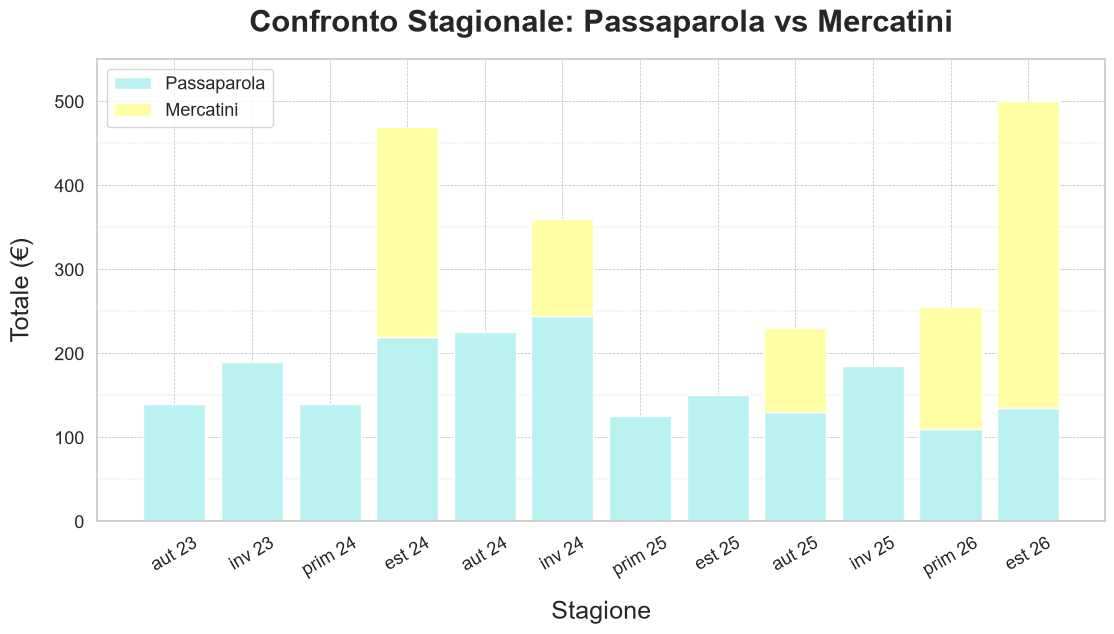

In [47]:
#GRAFICO 1
#questo ci piace e lo mettiamo
fig, ax = plt.subplots(figsize = (13, 6))

plt.bar(df_stagionale["stagione"], df_stagionale["passaparola"], label="Passaparola", color=colori[9])
plt.bar(df_stagionale["stagione"], df_stagionale["mercatini"], bottom=df_stagionale["passaparola"], label="Mercatini", color=colori[8])

ax.grid(True, color = "#BBBBBB", linewidth = 0.5, linestyle="--")
ax.grid(True, axis = 'y', which = 'minor',linewidth = 0.3, linestyle="--")

ax.set_xlabel("Stagione", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_ylabel("Totale (€)", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_title("Confronto Stagionale: Passaparola vs Mercatini", pad = 20, fontsize = 22, fontweight = "bold")

ax.yaxis.set_major_locator(plt.MultipleLocator(100))
ax.yaxis.set_minor_locator(plt.MultipleLocator(50))
ax.set_ylim(0, 550)

plt.xticks(rotation=30)
plt.legend(loc="upper left")

plt.savefig("Immagini/Passaparola-Mercatini.svg", bbox_inches = "tight", pad_inches = 0.3, transparent = False)
plt.savefig("Immagini/Passaparola-Mercatini.png", bbox_inches = "tight", pad_inches = 0.3, transparent = False);

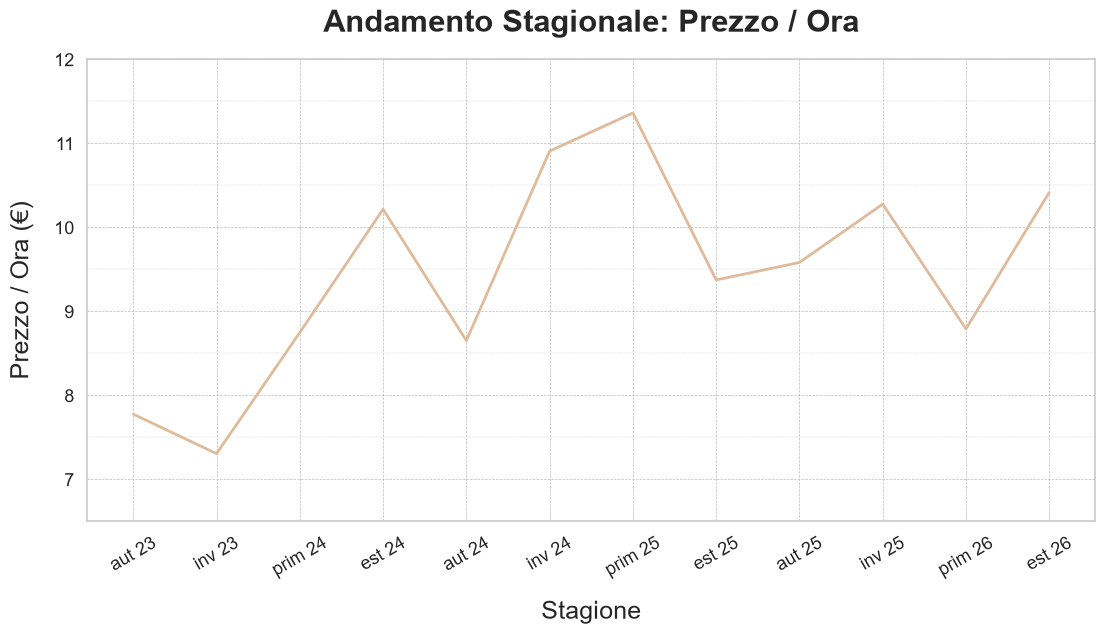

In [43]:
sns.set_theme(style="whitegrid", font_scale = 1.2)

fig, ax = plt.subplots(figsize = (13, 6))

sns.lineplot(
    data=df_stagionale, 
    x="stagione", 
    y="prezzo_ora", 
    linewidth=2, 
    color=colori[5])

ax.set_facecolor("#FFFFFF")

ax.grid(True, color = "#BBBBBB", linewidth = 0.5, linestyle="--")
ax.grid(True, axis = 'y', which = 'minor',linewidth = 0.3, linestyle="--")

ax.set_title("Andamento Stagionale: Prezzo / Ora", pad = 20, fontsize = 22, fontweight = "bold")
ax.set_xlabel("Stagione", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_ylabel("Prezzo / Ora (€)", fontsize = 18, fontweight = "normal", labelpad = 15)

ax.yaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.set_ylim(6.5, 12)

plt.xticks(rotation=30)

plt.savefig("Immagini/Prezzo-Ora.svg", bbox_inches = "tight", pad_inches = 0.3, transparent = False)
plt.savefig("Immagini/Prezzo-Ora.png", bbox_inches = "tight", pad_inches = 0.3, transparent = False);